# Tasca S10.01. Analítica de dades en Pandas

**Descripció**
 
En aquesta tasca t’enfrontaràs a un exercici de neteja i analítica de dades.

Tenim un dataset provinent d’una enquesta als nostres treballadors i treballadors, i hem de garantir que les dades es processes correctament, tant en format com en llegibilitat.

## Importar llibreries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, date

## Llegir documents

In [2]:
FILE_SPRINT10 = './data/raw/sprint10.xlsx'
FILE_MATRIU = './data/raw/matriu_distancies.xlsx'

## Nivell 1

### 1.

Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

- Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
- Mostra les primeres 10 files.
- Addicionalment, fes un print on comprovi que el DNI només té valors únics.

**Importar dataframe**

In [3]:
df_sprint10 = pd.read_excel(FILE_SPRINT10, header=3, index_col=0) # comprovat prèviament que la columna 0 tenia valors únics per a cada fila (carregant el df sense index_col i nunique, amb 1000).
df_sprint10.head(2)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A


In [4]:
df_sprint10_raw = df_sprint10.copy()

In [5]:
df_sprint10.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nom                1000 non-null   str    
 1   Cognoms            1000 non-null   str    
 2   DNI                1000 non-null   str    
 3   País d'origen      1000 non-null   str    
 4   Ciutat             1000 non-null   str    
 5   Dia de Naixement   1000 non-null   int64  
 6   Mes de Naixement   1000 non-null   int64  
 7   Any de Naixement   1000 non-null   int64  
 8   Gènere             1000 non-null   str    
 9   Salari mensual     1000 non-null   str    
 10  Fills              406 non-null    float64
 11  No Fills           594 non-null    float64
 12  Grup Professional  1000 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 101.7 KB


Neteja de noms de columnes

In [6]:
df_sprint10.columns = df_sprint10.columns.str.lower().str.replace(' ', '_', regex = False).str.replace("d'", "", regex = False)

In [7]:
df_sprint10.columns

Index(['nom', 'cognoms', 'dni', 'país_origen', 'ciutat', 'dia_de_naixement',
       'mes_de_naixement', 'any_de_naixement', 'gènere', 'salari_mensual',
       'fills', 'no_fills', 'grup_professional'],
      dtype='str')

**Ordenar dataframe per pais i ciutat**

Netejar espais a pais_origen i ciutat

In [8]:
df_sprint10['país_origen'] = df_sprint10['país_origen'].str.strip()
df_sprint10['ciutat'] = df_sprint10['ciutat'].str.strip()

In [9]:
df_sprint10.sort_values(by=['país_origen','ciutat'], inplace=True)
df_sprint10.reset_index(drop=True, inplace=True) # si ho faig seguit dóna error perquè inplace=True no es pot encadenar perquè retorna None. Segons chatGPT cada cop menys recomanat i millor declarar primer la variable i després el reset_index.
df_sprint10.head(2)

,nom,cognoms,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B


**Primeres 10 files**

In [10]:
df_sprint10.head(10)

,nom,cognoms,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
5,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
6,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
7,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
8,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
9,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


**Comprovar DNI només té valors únics**

In [11]:
files_totals = df_sprint10.shape[0]
DNI_unics = df_sprint10['dni'].nunique()

print(f'El DNI té valors únics donat que per a un total de {files_totals} files, hi ha {DNI_unics} valors únics de DNI.')

El DNI té valors únics donat que per a un total de 1000 files, hi ha 1000 valors únics de DNI.


### 2.

- Crea una columna que sigui el nom complet.
- Crea una columna si la persona és nascuda a Espanya o no.
- Posa el DNI com a índex del DataFrame (noms de files).
- Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
- Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

Mostra tots els canvis que has realitzat en una sola taula.

**Creació columna amb nom complet**

In [12]:
df_sprint10.insert(2, "nom_complet", df_sprint10['nom'] + ' ' + df_sprint10['cognoms'])
df_sprint10.head(2)

,nom,cognoms,nom_complet,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional
0,Mia,Schneider Fischer,Mia Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,Laura Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B


**Creació columna persona nascuda a Espanya**  
Primer neteja de possibles espais en blanc i comprovació de valors únics per si hi ha duplicats.

In [13]:
df_sprint10['país_origen'].unique()

<StringArray>
[  'Alemanya',  'Argentina',   'Colòmbia',    'Espanya',     'França',
     'Itàlia',     'Marroc',      'Mèxic',   'Portugal', 'Regne Unit']
Length: 10, dtype: str

In [14]:
df_sprint10['origen_espanya'] = np.where(df_sprint10['país_origen'] == 'Espanya', True, False)
df_sprint10.head(2)

,nom,cognoms,nom_complet,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
0,Mia,Schneider Fischer,Mia Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,False
1,Laura,Schneider Fischer,Laura Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,False


**DNI com a índex del DataFrame**

In [15]:
df_sprint10.set_index('dni', inplace=True)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,False
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,False


**Substitució nom de les columnes**  
Donat que ho he transformat tot a minúscules poso els nous noms de les columnes en minúscula.

In [16]:
df_sprint10.rename(columns={"dia_de_naixement":"dia", "mes_de_naixement":"mes", "any_de_naixement":"any"}, inplace=True)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,False
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,False


**Substitució H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na)**  
- Primer he comprovat els valors únics de gènere així com quants valors hi ha de cadascú i si hi ha nulls
- Després he fet la substitutció
- Finalment he comprovat  que s'hagi fet correctament amb el nombre de nulls de la columna

In [17]:
df_sprint10['gènere'].value_counts()

gènere
H     449
D     440
NC     60
A      51
Name: count, dtype: int64

In [18]:
df_sprint10['gènere'].isnull().sum()

np.int64(0)

In [19]:
df_sprint10['gènere'] = df_sprint10['gènere'].replace({'A':'Altres','D':'Dona','H':'Home','NC':np.nan})
df_sprint10['gènere'].unique()

<StringArray>
['Altres', 'Dona', 'Home', nan]
Length: 4, dtype: str

In [20]:
df_sprint10['gènere'].isnull().sum()

np.int64(60)

**Mostrar canvis en una taula**  
He creat un df on només apareixen les columnes modificades i també printo el df original amb els canvis (amb les columnes no modificades)

In [21]:
df_sprint10_canvis = df_sprint10.loc[:,['nom_complet','origen_espanya', 'dia','mes','any','gènere']]
df_sprint10_canvis

,nom_complet,origen_espanya,dia,mes,any,gènere
dni,,,,,,
28973553Z,Mia Schneider Fischer,False,22,10,1976,Altres
37399141L,Laura Schneider Fischer,False,2,2,1958,Dona
37368317L,Lea Schneider Schneider,False,23,10,2005,Dona
21390098Z,Mia Fischer,False,11,8,1950,Dona
44060014R,Jonas Schneider,False,22,11,1985,Home
...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,False,28,3,1958,Dona
57441590Y,George Brown Jones,False,27,12,1979,Home
58204038A,Olivia Brown Brown,False,28,8,1952,Altres


In [22]:
df_sprint10

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,False
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,False
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,False
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,False
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,False


#### Altres comprovacions 

In [23]:
df_sprint10['país_origen'][df_sprint10['país_origen'].str.startswith('E')].unique()

<StringArray>
['Espanya']
Length: 1, dtype: str

In [24]:
df_sprint10.loc[df_sprint10['país_origen'] == 'Espanya']

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
27724652S,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,1.253 €,1.0,NaN,Grup A,True
69630528M,Toni,Sánchez García,Toni Sánchez García,Espanya,Barcelona,9,8,1999,Home,1.043 €,NaN,1.0,Grup A,True
14219925Z,Toni,Martínez,Toni Martínez,Espanya,Barcelona,16,5,1964,Home,891 €,NaN,1.0,Grup A,True
40695825B,Oriol,Sánchez,Oriol Sánchez,Espanya,Barcelona,27,7,1965,Home,1.250 €,NaN,1.0,Grup A,True
74222289K,Toni,Castells Romero,Toni Castells Romero,Espanya,Barcelona,13,4,1961,Home,1.438 €,NaN,1.0,Grup B,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42807414J,Laia,Sánchez,Laia Sánchez,Espanya,València,17,7,1967,Dona,2.255 €,NaN,1.0,Grup C,True
38147748A,Núria,Martínez Ferrer,Núria Martínez Ferrer,Espanya,València,4,11,1976,Dona,1.028 €,NaN,1.0,Grup A,True
48749091Z,Oriol,Sánchez García,Oriol Sánchez García,Espanya,València,16,7,1965,Home,1.273 €,NaN,1.0,Grup A,True


### 3.

Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

COmprovar els valors únics

In [25]:
display(df_sprint10['fills'].unique())
display(df_sprint10['no_fills'].unique())

array([nan,  1.])

array([ 1., nan])

Crear la funció

In [26]:
def fills(row):
    if row["fills"] == 1.0:
        return 'Sí'
    elif row["no_fills"] == 1.0:
        return 'No'
    else:
        return np.nan

Aplicar la funció

In [27]:
df_sprint10['Fills'] = df_sprint10.apply(fills, axis=1)

Comprovar resultat

In [28]:
df_sprint10['Fills'].unique()

<StringArray>
['No', 'Sí']
Length: 2, dtype: str

In [29]:
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills
dni,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí


### 4.

- Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
- Ordena la taula en funció del sou mig.

Preprocessament columna salari_mensual

In [30]:
df_sprint10.dtypes

nom                      str
cognoms                  str
nom_complet              str
país_origen              str
ciutat                   str
dia                    int64
mes                    int64
any                    int64
gènere                   str
salari_mensual           str
fills                float64
no_fills             float64
grup_professional        str
origen_espanya          bool
Fills                    str
dtype: object

Creació nova columna

In [31]:
df_sprint10['salari_mensual_int'] = (
    df_sprint10['salari_mensual']
    .str.replace(r"\D", "", regex=True)
    .astype(int)
)
df_sprint10.head(2)


,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills,salari_mensual_int
dni,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769


Comprovar moneda salari

In [32]:
df = df_sprint10[['salari_mensual']]
df['moneda_salari'] = df['salari_mensual'].str[-1]
print(f'Valors únics:\n{df['moneda_salari'].unique()}\n')
print(f'Valors nuls:\n {df['moneda_salari'].isnull().sum()}')


Valors únics:
<StringArray>
['€']
Length: 1, dtype: str

Valors nuls:
 0


**Agrupació per taula descriptiva ordenada per salari mitjà**  
La primera conté els paràmetres demanats i la segona més descriptius

In [33]:
df_sprint10.groupby('gènere')['salari_mensual_int'].aggregate(['mean','median','min','max']).sort_values('mean')

,mean,median,min,max
gènere,,,,
Dona,1469.443182,1361.5,665,3021
Altres,1626.588235,1545.0,703,3175
Home,1643.249443,1531.0,737,3356


In [34]:
df_sprint10.groupby('gènere')['salari_mensual_int'].describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
gènere,,,,,,,,
Dona,440.0,1469.443182,542.084117,665.0,1080.0,1361.5,1785.25,3021.0
Altres,51.0,1626.588235,611.906502,703.0,1198.0,1545.0,2018.00,3175.0
Home,449.0,1643.249443,582.576463,737.0,1239.0,1531.0,2027.00,3356.0


### 5.

- Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
- Afegeix-hi les mitjanes als marges de la taula.

**Taula resum salari mig per gènere i país d'origen amb mitjanes als marges de la taula**

In [35]:
crosstab = pd.crosstab(df_sprint10['gènere'],df_sprint10['país_origen'], df_sprint10['salari_mensual_int'], aggfunc='mean', margins=True, margins_name='mitjana').round(2)
crosstab

país_origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,mitjana
gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
mitjana,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


Comprovar que a França no hi ha persones de gènere Altres

In [36]:
df_sprint10['gènere'][df_sprint10['país_origen'] == 'França'].unique()

<StringArray>
['Home', 'Dona', nan]
Length: 3, dtype: str

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

**Taula resum salari mig per gènere i país d'origen amb format condicional per valors**

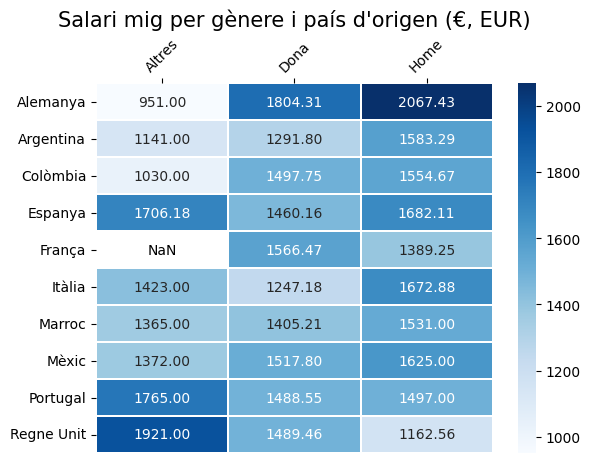

In [37]:
data = pd.crosstab(df_sprint10['país_origen'], df_sprint10['gènere'], df_sprint10['salari_mensual_int'], aggfunc='mean')

# plot heatmap

ax = sns.heatmap(data, cmap="Blues", annot = True, linewidth=0.3, fmt=".2f") #annot són valors per cel·la, fmt el nombre de decimals, linewidth la linia blanca entre cel·les

# xticks
ax.xaxis.tick_top()
plt.xticks(plt.xticks()[0], rotation=45)

# yticks
plt.yticks(plt.yticks()[0], rotation=0)

# axis labels
plt.xlabel('')
plt.ylabel('')

# annotate 'NaN', recórrer cada cel·la del heatmap (cada combinació fila-columna) i si és NaN escriure 'NaN' (ax.text)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if pd.isna(data.iloc[i, j]):
            ax.text(j + 0.5, i + 0.5, 'NaN',
                    ha='center', va='center')

#title
title = "Salari mig per gènere i país d'origen (€, EUR)"
plt.title(title, fontsize=15)
          
plt.show()

### 6.

- Crea una columna nova que sigui la data de naixement en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
- Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [38]:
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills,salari_mensual_int
dni,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769


**Creació nova columna data naixement en format datetime**

In [39]:
df_sprint10['data_naixement'] = pd.to_datetime(df_sprint10['any'].astype(str) + '/' + df_sprint10['mes'].astype(str) + '/' + df_sprint10['dia'].astype(str))
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills,salari_mensual_int,data_naixement
dni,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951,1976-10-22
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769,1958-02-02


Comprovació format datetime

In [40]:
df_sprint10.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 28973553Z to 82046699J
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   nom                 1000 non-null   str           
 1   cognoms             1000 non-null   str           
 2   nom_complet         1000 non-null   str           
 3   país_origen         1000 non-null   str           
 4   ciutat              1000 non-null   str           
 5   dia                 1000 non-null   int64         
 6   mes                 1000 non-null   int64         
 7   any                 1000 non-null   int64         
 8   gènere              940 non-null    str           
 9   salari_mensual      1000 non-null   str           
 10  fills               406 non-null    float64       
 11  no_fills            594 non-null    float64       
 12  grup_professional   1000 non-null   str           
 13  origen_espanya      1000 non-null   bool          


In [41]:
df_sprint10.loc[['28973553Z'], 'data_naixement'].dt.month

dni
28973553Z    10
Name: data_naixement, dtype: int32

**Funció càlcul edat data d'avui**

In [42]:
def calcul_edat(data_naixement: datetime) -> int:
    """
    Calcula l'edat actual a partir de la data de naixement.

    L'edat es calcula tenint en compte si l'aniversari d'aquest any
    ja ha passat o no.

    Args:
        data_naixement (datetime): Data de naixement de la persona.

    Returns:
        int: Edat actual en anys.
    """
    data_actual = date.today()
    edat_actual = data_actual.year - data_naixement.year - ((data_actual.month, data_actual.day) < (data_naixement.month, data_naixement.day))
    # Comparació de tuples: primer compara mesos i si són iguals compara dies. El resultat és True (1) o False(0). SI no ha passat l'aniversari, resta un any.

    return edat_actual

**Creació columna edat_actual a partir de la funció**

In [43]:
df_sprint10['edat_actual'] = df_sprint10['data_naixement'].apply(calcul_edat)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills,salari_mensual_int,data_naixement,edat_actual
dni,,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951,1976-10-22,49
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769,1958-02-02,68


## Nivell 2

### 1.

- Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
- Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

```
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
```
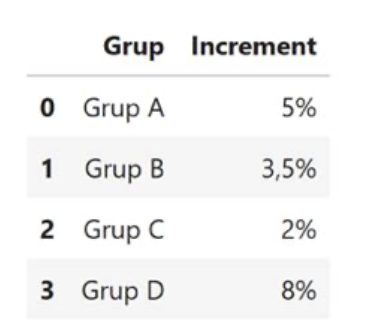

Creació dataframe

In [44]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


Neteja valors dataframe

In [45]:
df_increment['Increment'] = df_increment['Increment'].str.replace('%', '').str.replace(',', '.').astype(float)
df_increment

,Grup,Increment
0,Grup A,5.0
1,Grup B,3.5
2,Grup C,2.0
3,Grup D,8.0


In [46]:
df_increment.rename(columns={'Grup':'grup_professional','Increment':'increment'}, inplace=True) # per a poder fer el merge amb només un nom ID

**Adjuntar la columna increment al df anterior (df_sprint10)**

In [47]:
df_sprint10 = pd.merge(df_sprint10,df_increment, on='grup_professional')
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills,salari_mensual_int,data_naixement,edat_actual,increment
0,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951,1976-10-22,49,5.0
1,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769,1958-02-02,68,3.5


**Actualització columna salari (salari_mensual_int) en funció dels percentatges que s'adjunten**

In [48]:
df_sprint10['salari_mensual_int'] = df_sprint10['salari_mensual_int'] + (df_sprint10['salari_mensual_int'] * (df_sprint10['increment']/100)).round(2)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya,Fills,salari_mensual_int,data_naixement,edat_actual,increment
0,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,998.55,1976-10-22,49,5.0
1,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1830.92,1958-02-02,68,3.5


### 2.

Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [49]:
grups = df_sprint10['grup_professional'].unique().tolist()

Crear funció guardar df a csv

In [50]:
def guardar_csv(df: pd.DataFrame, nom: str) -> str:
    timestamp = datetime.now().strftime("%Y%m%d%H%M")
    path = f'./data/processed/dades_{nom}_{timestamp}.xlsx'
    df.to_csv(path, index=False)
    return path

**Exportar dades group professionals amb un bucle**

In [51]:
for grup in grups:
    df = df_sprint10[df_sprint10['grup_professional'] == grup]
    nom_grup = grup.replace(' ','')
    path = guardar_csv(df,nom_grup)
    print(path)

./data/processed/dades_GrupA_202603211346.xlsx
./data/processed/dades_GrupB_202603211346.xlsx
./data/processed/dades_GrupD_202603211346.xlsx
./data/processed/dades_GrupC_202603211346.xlsx


**Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.**

Creació df amb descriptius

In [52]:
df_grups_descriptius = df_sprint10.groupby('grup_professional').agg(
    salari_mitja=('salari_mensual_int', lambda x: round(x.mean(), 2)),
    edat_mediana=('edat_actual', 'median')
).reset_index()
display(df_grups_descriptius)

,grup_professional,salari_mitja,edat_mediana
0,Grup A,1213.32,51.0
1,Grup B,1724.55,47.5
2,Grup C,2289.19,52.0
3,Grup D,3100.82,43.0


In [53]:
path = guardar_csv(df_grups_descriptius, 'grups_descriptius')
print(path)

./data/processed/dades_grups_descriptius_202603211346.xlsx


## Nivell 3

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

### 1.

Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

- un histograma/boxplot si la variable és numèrica
- unes barres dels valors més freqüents si és categòrica
- unes barres dels anys més freqüents si la dada està en format data.

La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, *iris, penguins* o *titanic*.

**Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.**

### 2.
 Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: [Mejores Rutas](https://espana.mejoresrutas.com/tabla-de-distancias/es/)

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

**No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.**

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat?

## Pàgines web


- [Sorting a Pandas DataFrame by a Single Column](https://medium.com/@whyamit404/sorting-a-pandas-dataframe-by-a-single-column-7c035cc64289)
- [How to Sort Pandas DataFrame?](https://www.geeksforgeeks.org/pandas/how-to-sort-pandas-dataframe/)

- [Python | Pandas DataFrame.set_index()](https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-set_index/)

*Heatmap Seaborn*:
- https://tutegomeze.medium.com/conceptos-b%C3%A1sicos-de-heatmap-con-seaborn-ea074be662ea
- https://www.geeksforgeeks.org/python/how-to-change-seaborn-legends-font-size-location-and-color/
- https://seaborn.pydata.org/generated/seaborn.heatmap.html

- [Convert birth date to age in Pandas](https://www.geeksforgeeks.org/python/convert-birth-date-to-age-in-pandas/)